/home/nottheorion/IPCV_project/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - acc: 0.7342 - loss: 0.5998 - val_acc: 0.8843 - val_loss: 0.3105
Epoch 2/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - acc: 0.8104 - loss: 0.4338 - val_acc: 0.8810 - val_loss: 0.2749
Epoch 3/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - acc: 0.8345 - loss: 0.4003 - val_acc: 0.8793 - val_loss: 0.2963
Epoch 4/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - acc: 0.8378 - loss: 0.3869 - val_acc: 0.8942 - val_loss: 0.2583
Epoch 5/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - acc: 0.8453 - loss: 0.3648 - val_acc: 0.8826 - val_loss: 0.2803
Epoch 6/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - acc: 0.8519 - loss: 0.3600 - val_acc: 0.9041 - val_loss: 0.2487
Epoch 7/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - acc: 0.8518 - loss: 0.3518 - val_acc: 0.9223 - val_loss: 0.2098
Epoch 8/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - acc: 0.8593 - loss: 0.3445 - val_acc: 0.9074 - val_loss: 0.2318
Epoch 9/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 7s

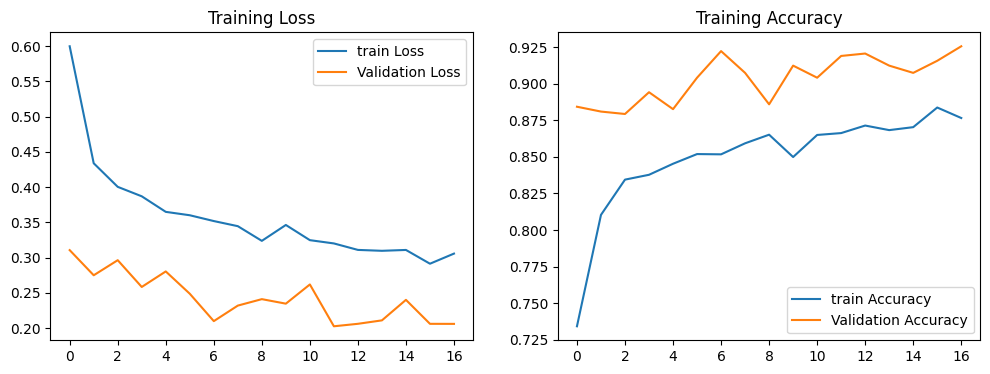

Model saved


In [ ]:
import os

#----Dev Note: the three lines below are device specific. Without it, Tensorflow crashes and burns.
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import keras
import cv2
import pandas as pd
with_mask_path = os.path.join("dataset","data/with_mask")
without_mask_path = os.path.join("dataset","data/without_mask")

data = []

for img_file in os.listdir(with_mask_path):
    img_path = os.path.join(with_mask_path, img_file)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224,224))
    image = np.array(image)
    data.append({
        "image": image,
        "label": 1,
    })


for img_file in os.listdir(without_mask_path):
    img_path = os.path.join(without_mask_path, img_file)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224,224))
    image = np.array(image)
    data.append({
        "image": image,
        "label": 0,
    })


df = pd.DataFrame(data)


X = np.array(df["image"].tolist())
Y = np.array(df["label"].tolist())

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y,random_state=42)

X_train_scaled = X_train.astype("float32") / 255.0
x_test_scaled = X_test.astype("float32") / 255.0

aug_data =  keras.models.Sequential([
            
            keras.layers.RandomRotation(factor=0.055),
            keras.layers.RandomZoom(height_factor=0.15),
            keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
            keras.layers.RandomFlip("horizontal"),

            ])

model = keras.Sequential([
    aug_data,
    keras.layers.Conv2D(32,kernel_size=(3,3), activation="relu", input_shape=(224,224,3)),
    keras.layers.MaxPool2D(pool_size=(2,2)),

    keras.layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    keras.layers.MaxPool2D(pool_size=(2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),

    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(2, activation="softmax"),


])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["acc"],jit_compile=False)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,          
    restore_best_weights=True
)
history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=50, callbacks=[early_stopping])
loss, accuracy = model.evaluate(x_test_scaled, y_test)

print(f"Test Accuracy - {accuracy}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(history.history["acc"], label="train Accuracy")
plt.plot(history.history["val_acc"], label="Validation Accuracy")
plt.legend()
plt.title("Training Accuracy")

plt.show()

model.save("models/mask_detector_scratch_model.keras")
print("Model saved")

